# Research QuantBook: TrendStocks Alpha Model

## Objectif
Analyser la stratégie TrendStocks (double confirmation SMA200 + EMA20/50) sur 15 actions
diversifiées via QuantBook, pour valider les résultats avant déploiement.

## Stratégie
- **Univers**: 15 actions (5 tech + 10 diversifiées: financials, healthcare, energy, staples)
- **Signal**: Prix > SMA200 ET EMA20 > EMA50 (double confirmation)
- **Rebalancement**: Hebdomadaire

## Performance de référence
Sharpe 0.609 (2020-2025) - solide avec diversification sectorielle.

## Hypothèses à tester
1. Période EMA optimale: (15/45), (20/50), (25/55)
2. Période SMA200: 150, 200, 250
3. Rebalancement: daily vs weekly vs monthly

## Prérequis
- Environnement Lean Research
- Durée estimée: ~5 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les 15 actions de l'univers TrendStocks.

In [2]:
# Univers TrendStocks: 5 tech + 10 diversifiées
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",  # Tech
    "JPM", "V", "MA",                            # Financials
    "UNH", "JNJ",                                 # Healthcare
    "XOM", "CVX",                                 # Energy
    "HD", "PG", "KO"                             # Consumer staples
]

symbols = {}
for ticker in tickers:
    symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

# Charger l'historique (2015-2026)
start = datetime(2015, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 5532 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour TrendStocks-Alpha.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.dropna()

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"Tickers: {list(closes.columns)}")

Période: 2015-01-02 à 2025-12-31
Données: 2766 jours de trading
Tickers: ['AAPL', 'GOOGL']


## 2. Implémentation du signal TrendStocks

In [4]:
def compute_trend_stocks_signals(closes, tickers, ema_fast=20, ema_slow=50, sma_trend=200):
    """Génère les signaux TrendStocks (double confirmation)."""
    signals = pd.DataFrame(index=closes.index, columns=tickers)
    
    for ticker in tickers:
        if ticker not in closes.columns:
            continue
        price = closes[ticker]
        ema_f = price.ewm(span=ema_fast, adjust=False).mean()
        ema_s = price.ewm(span=ema_slow, adjust=False).mean()
        sma_200 = price.rolling(sma_trend).mean()
        
        # Double confirmation: prix > SMA200 ET EMA20 > EMA50
        price_above_sma = price > sma_200
        ema_bullish = ema_f > ema_s
        signals[ticker] = (price_above_sma & ema_bullish).astype(int)
    
    return signals

# Signaux avec paramètres par défaut
signals = compute_trend_stocks_signals(closes, tickers)

print("Signaux TrendStocks (derniers 5 jours):")
print(signals.iloc[-5:])
print(f"\nNombre moyen de positions: {signals.sum(axis=1).mean():.1f} sur {len(tickers)}")

Signaux TrendStocks (derniers 5 jours):
                     AAPL MSFT  GOOGL AMZN NVDA  JPM    V   MA  UNH  JNJ  XOM  \
time                                                                            
2025-12-24 13:00:00     0  NaN      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2025-12-26 16:00:00     0  NaN      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2025-12-29 16:00:00     0  NaN      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2025-12-30 16:00:00     0  NaN      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2025-12-31 16:00:00     0  NaN      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

                     CVX   HD   PG   KO  
time                                     
2025-12-24 13:00:00  NaN  NaN  NaN  NaN  
2025-12-26 16:00:00  NaN  NaN  NaN  NaN  
2025-12-29 16:00:00  NaN  NaN  NaN  NaN  
2025-12-30 16:00:00  NaN  NaN  NaN  NaN  
2025-12-31 16:00:00  NaN  NaN  NaN  NaN  

Nombre moyen de positions: 0.8 sur 15


### Interprétation: Signal TrendStocks

- **Signal = 1**: Double confirmation (trend long-terme + momentum court-terme)
- **Signal = 0**: Une des deux conditions n'est pas remplie

La double confirmation réduit les faux signaux par rapport à EMA-Cross simple.

## 3. Backtest de la stratégie TrendStocks

In [5]:
def backtest_trend_stocks(closes, signals, rebal_freq=5):
    """Backtest TrendStocks equally-weighted."""
    returns_df = closes.pct_change()
    portfolio_values = [1.0]
    
    warmup = 250
    counter = 0
    holdings = []
    
    for i in range(warmup, len(closes)):
        # Mise à jour holdings (hebdomadaire)
        counter += 1
        if counter >= rebal_freq:
            counter = 0
            holdings = [t for t in signals.columns if signals[t].iloc[i] == 1]
        elif i == warmup:
            holdings = [t for t in signals.columns if signals[t].iloc[i] == 1]
        
        # Calcul du return
        port_return = 0.0
        if len(holdings) > 0:
            weight_per_stock = 1.0 / len(holdings)
            for t in holdings:
                if t in returns_df.columns:
                    port_return += weight_per_stock * returns_df[t].iloc[i]
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

print("Fonction de backtest définie.")

Fonction de backtest définie.


## 4. Test des périodes EMA

In [6]:
# Test différentes périodes EMA
ema_pairs = [
    (15, 45, "EMA15/45"),
    (20, 50, "EMA20/50"),
    (25, 55, "EMA25/55"),
]

results = {}

print(f"{'Période EMA':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Vol':>8}")
print("-" * 50)

for fast, slow, name in ema_pairs:
    sig = compute_trend_stocks_signals(closes, tickers, ema_fast=fast, ema_slow=slow)
    r = backtest_trend_stocks(closes, sig)
    results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

best_ema = max(results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période EMA: {best_ema[0]} (Sharpe={best_ema[1]['sharpe']:.3f})")

Période EMA    Sharpe     CAGR    MaxDD      Vol
--------------------------------------------------


EMA15/45        0.478   10.0%  -25.5%   14.7%


EMA20/50        0.281    7.2%  -20.9%   14.9%


EMA25/55        0.199    6.3%  -26.5%   16.8%

Meilleure période EMA: EMA15/45 (Sharpe=0.478)


## 5. Test de la période SMA200

In [7]:
# Test différentes périodes SMA
sma_periods = [150, 200, 250]

print(f"{'Période SMA':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

sma_results = {}
for sma_p in sma_periods:
    sig = compute_trend_stocks_signals(closes, tickers, sma_trend=sma_p)
    r = backtest_trend_stocks(closes, sig)
    sma_results[sma_p] = r
    print(f"SMA{sma_p:<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_sma = max(sma_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période SMA: {best_sma[0]} (Sharpe={best_sma[1]['sharpe']:.3f})")

Période SMA    Sharpe     CAGR    MaxDD
----------------------------------------


SMA150          0.276    7.1%  -22.6%


SMA200          0.281    7.2%  -20.9%


SMA250          0.324    7.8%  -20.3%

Meilleure période SMA: 250 (Sharpe=0.324)


## 6. Test du rebalancement

In [8]:
# Test fréquences de rebalancement
rebal_freqs = [
    (1, "Daily"),
    (5, "Weekly"),
    (21, "Monthly"),
]

print(f"{'Rebalancement':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

sig = compute_trend_stocks_signals(closes, tickers)
rebal_results = {}
for freq, name in rebal_freqs:
    r = backtest_trend_stocks(closes, sig, rebal_freq=freq)
    rebal_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Rebalancement   Sharpe     CAGR    MaxDD
----------------------------------------


Daily           0.595   11.8%  -18.4%


Weekly          0.281    7.2%  -20.9%
Monthly         0.239    7.1%  -30.9%


## 7. Visualisation des equity curves

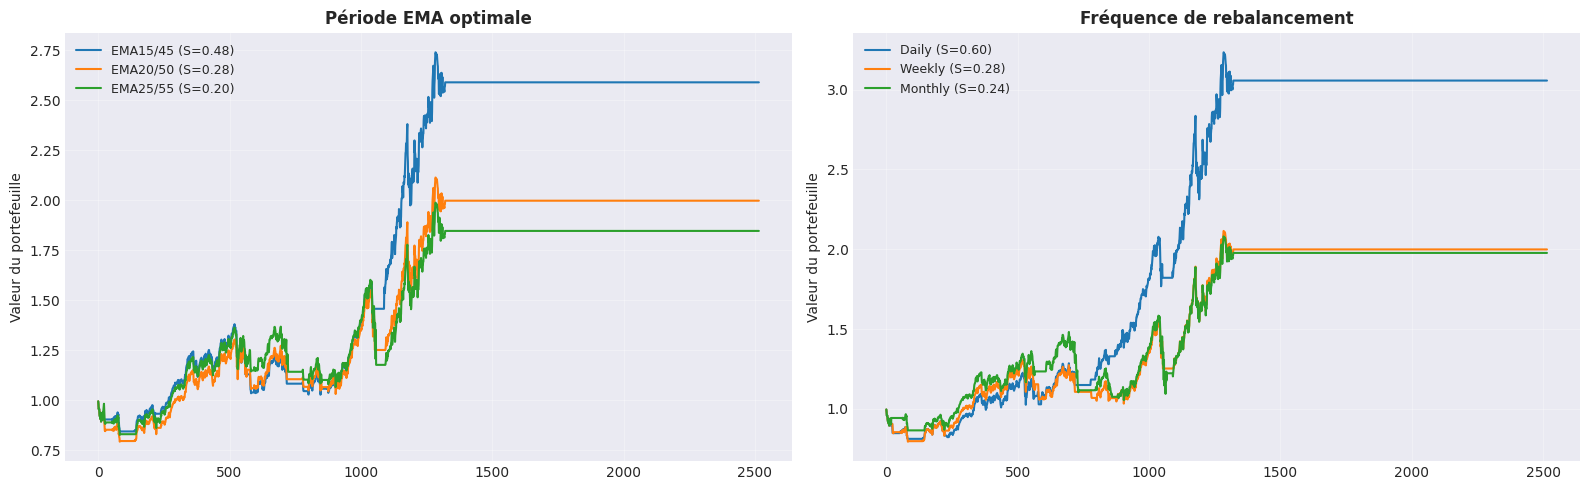

Graphique sauvegardé.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Comparaison des périodes EMA
ax = axes[0]
for name, r in results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('Période EMA optimale', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Droite: Comparaison des rebalancements
ax = axes[1]
for name, r in rebal_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('Fréquence de rebalancement', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trend_stocks_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 8. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Période EMA | (à remplir) |
| Période SMA | (à remplir) |
| Rebalancement | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.6: **Déployer avec les paramètres optimaux**

### Prochaines étapes

1. Déployer TrendStocks-Alpha sur QC cloud
2. Tester l'univers sectoriel par secteur
3. Combiner avec EMA-Cross dans un composite